In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
with Path("big_eval_new.json").open("r") as f:
    rag_data: list[dict[str, str | dict[str, str | int]]] = json.load(f)

with Path("rag_triangle_zero_shot.json").open("r") as f:
    zero_shot_data: list[dict[str, str | dict[str, str | int]]] = json.load(f)

In [3]:
with Path("rag_triad_5.json").open("r") as f:
    rag_data: list[dict[str, str | dict[str, str | int]]] = json.load(f)

with Path("rag_triad_5_zero_shot.json").open("r") as f:
    zero_shot_data: list[dict[str, str | dict[str, str | int]]] = json.load(f)

In [4]:
def get_df(data: list[dict[str, str | dict[str, str | int]]]) -> pd.DataFrame:
    df = [
        (
            d.get("model"),
            d.get("idx"),
            d.get("rag").get("context_relevance"), # type: ignore
            d.get("rag").get("answer_relevance"), # type: ignore
            d.get("rag").get("groundedness"), # type: ignore
        )
        for d in data
    ]

    return pd.DataFrame(
        df,
        columns=["model", "idx", "context_relevance", "answer_relevance", "groundedness"]
    )

In [5]:
rag_df = get_df(rag_data)
rag_df.head()

,model,idx,context_relevance,answer_relevance,groundedness
0,DLR_FM_2.mistral-small:24b-instruct-2501-q8_0,CLIMATE INDICATORS_Exploratory,5,5,5
1,DLR_FM_2.mistral-small:24b-instruct-2501-q8_0,CLIMATE INDICATORS_Comparative,2,3,4
2,DLR_FM_2.mistral-small:24b-instruct-2501-q8_0,CLIMATE INDICATORS_Descriptive,5,5,5
3,DLR_FM_2.mistral-small:24b-instruct-2501-q8_0,CLIMATE INDICATORS_Causal,5,5,5
4,DLR_FM_2.mistral-small:24b-instruct-2501-q8_0,CLIMATE INDICATORS_Relational,5,4,4


In [6]:
zero_shot_df = get_df(zero_shot_data)
zero_shot_df.head()

,model,idx,context_relevance,answer_relevance,groundedness
0,DLR_FM_2.mistral-small:24b-instruct-2501-q8_0,CLIMATE INDICATORS_Exploratory,4,4,4
1,DLR_FM_2.mistral-small:24b-instruct-2501-q8_0,CLIMATE INDICATORS_Comparative,5,5,5
2,DLR_FM_2.mistral-small:24b-instruct-2501-q8_0,CLIMATE INDICATORS_Descriptive,5,5,5
3,DLR_FM_2.mistral-small:24b-instruct-2501-q8_0,CLIMATE INDICATORS_Causal,5,5,5
4,DLR_FM_2.mistral-small:24b-instruct-2501-q8_0,CLIMATE INDICATORS_Relational,5,5,5


In [7]:
rag_df_mistral = rag_df[rag_df["model"] == "DLR_FM_2.mistral-small:24b-instruct-2501-q8_0"]
rag_df_llama = rag_df[rag_df["model"] == "DLR_FM_1.llama3.3:latest"]

zero_shot_df_mistral = zero_shot_df[zero_shot_df["model"] == "DLR_FM_2.mistral-small:24b-instruct-2501-q8_0"]
zero_shot_df_llama = zero_shot_df[zero_shot_df["model"] == "DLR_FM_1.llama3.3:latest"]

In [8]:
zero_shot_df_mistral

,model,idx,context_relevance,answer_relevance,groundedness
0,DLR_FM_2.mistral-small:24b-instruct-2501-q8_0,CLIMATE INDICATORS_Exploratory,4,4,4
1,DLR_FM_2.mistral-small:24b-instruct-2501-q8_0,CLIMATE INDICATORS_Comparative,5,5,5
2,DLR_FM_2.mistral-small:24b-instruct-2501-q8_0,CLIMATE INDICATORS_Descriptive,5,5,5
3,DLR_FM_2.mistral-small:24b-instruct-2501-q8_0,CLIMATE INDICATORS_Causal,5,5,5
4,DLR_FM_2.mistral-small:24b-instruct-2501-q8_0,CLIMATE INDICATORS_Relational,5,5,5
...,...,...,...,...,...
65,DLR_FM_2.mistral-small:24b-instruct-2501-q8_0,BIOLOGICAL CLASSIFICATION_Exploratory,2,5,1
66,DLR_FM_2.mistral-small:24b-instruct-2501-q8_0,BIOLOGICAL CLASSIFICATION_Comparative,3,4,3
67,DLR_FM_2.mistral-small:24b-instruct-2501-q8_0,BIOLOGICAL CLASSIFICATION_Descriptive,5,5,5
68,DLR_FM_2.mistral-small:24b-instruct-2501-q8_0,BIOLOGICAL CLASSIFICATION_Causal,2,5,3


In [9]:
def make_full_heatmap_data(data: pd.DataFrame, group_col: str, value_col: str) -> pd.DataFrame:
    """Create heatmap data by counting scores and filling missing values."""
    # range_ = list(range(4))
    range_ = np.arange(1, 6)
    return data.pivot_table(
        index=group_col,
        columns=value_col,
        aggfunc="size",
        fill_value=0
    ).reindex(index=range_, columns=range_, fill_value=0)

def plot_heatmaps(data: pd.DataFrame) -> None:
    """Plot two symmetric 4x4 heatmaps.

    (Answer Relevance and Groundedness vs Context Relevance).
    """
    required_columns = {"context_relevance", "answer_relevance", "groundedness"}
    if not required_columns.issubset(data.columns):
        msg = f"DataFrame must contain: {required_columns}"
        raise ValueError(msg)

    heatmap_context_answer = make_full_heatmap_data(data=data, group_col="context_relevance", value_col="answer_relevance")
    heatmap_context_ground = make_full_heatmap_data(data=data, group_col="context_relevance", value_col="groundedness")
    heatmap_answer_ground = make_full_heatmap_data(data=data, group_col="answer_relevance", value_col="groundedness")

    # Plotting
    _, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=300)

    sns_heat1 = sns.heatmap(heatmap_context_answer, cmap="Blues", annot=True, ax=axes[0], annot_kws={"size": 12})
    axes[0].set_xlabel("Answer Relevance", fontsize=14)
    axes[0].set_ylabel("Context Relevance", fontsize=14)
    axes[0].tick_params(axis="both", labelsize=12)
    sns_heat1.collections[0].colorbar.ax.tick_params(labelsize=12) # type: ignore

    sns_heat2 = sns.heatmap(heatmap_context_ground, cmap="Greens", annot=True, ax=axes[1], annot_kws={"size": 12})
    axes[1].set_xlabel("Groundedness", fontsize=14)
    axes[1].set_ylabel("Context Relevance", fontsize=14)
    axes[1].tick_params(axis="both", labelsize=12)
    sns_heat2.collections[0].colorbar.ax.tick_params(labelsize=12) # type: ignore

    sns_heat3 = sns.heatmap(heatmap_answer_ground, cmap="Oranges", annot=True, ax=axes[2], annot_kws={"size": 12})
    axes[2].set_xlabel("Groundedness", fontsize=14)
    axes[2].set_ylabel("Answer Relevance", fontsize=14)
    axes[2].tick_params(axis="both", labelsize=12)
    sns_heat3.collections[0].colorbar.ax.tick_params(labelsize=12) # type: ignore

    plt.tight_layout()
    plt.show()

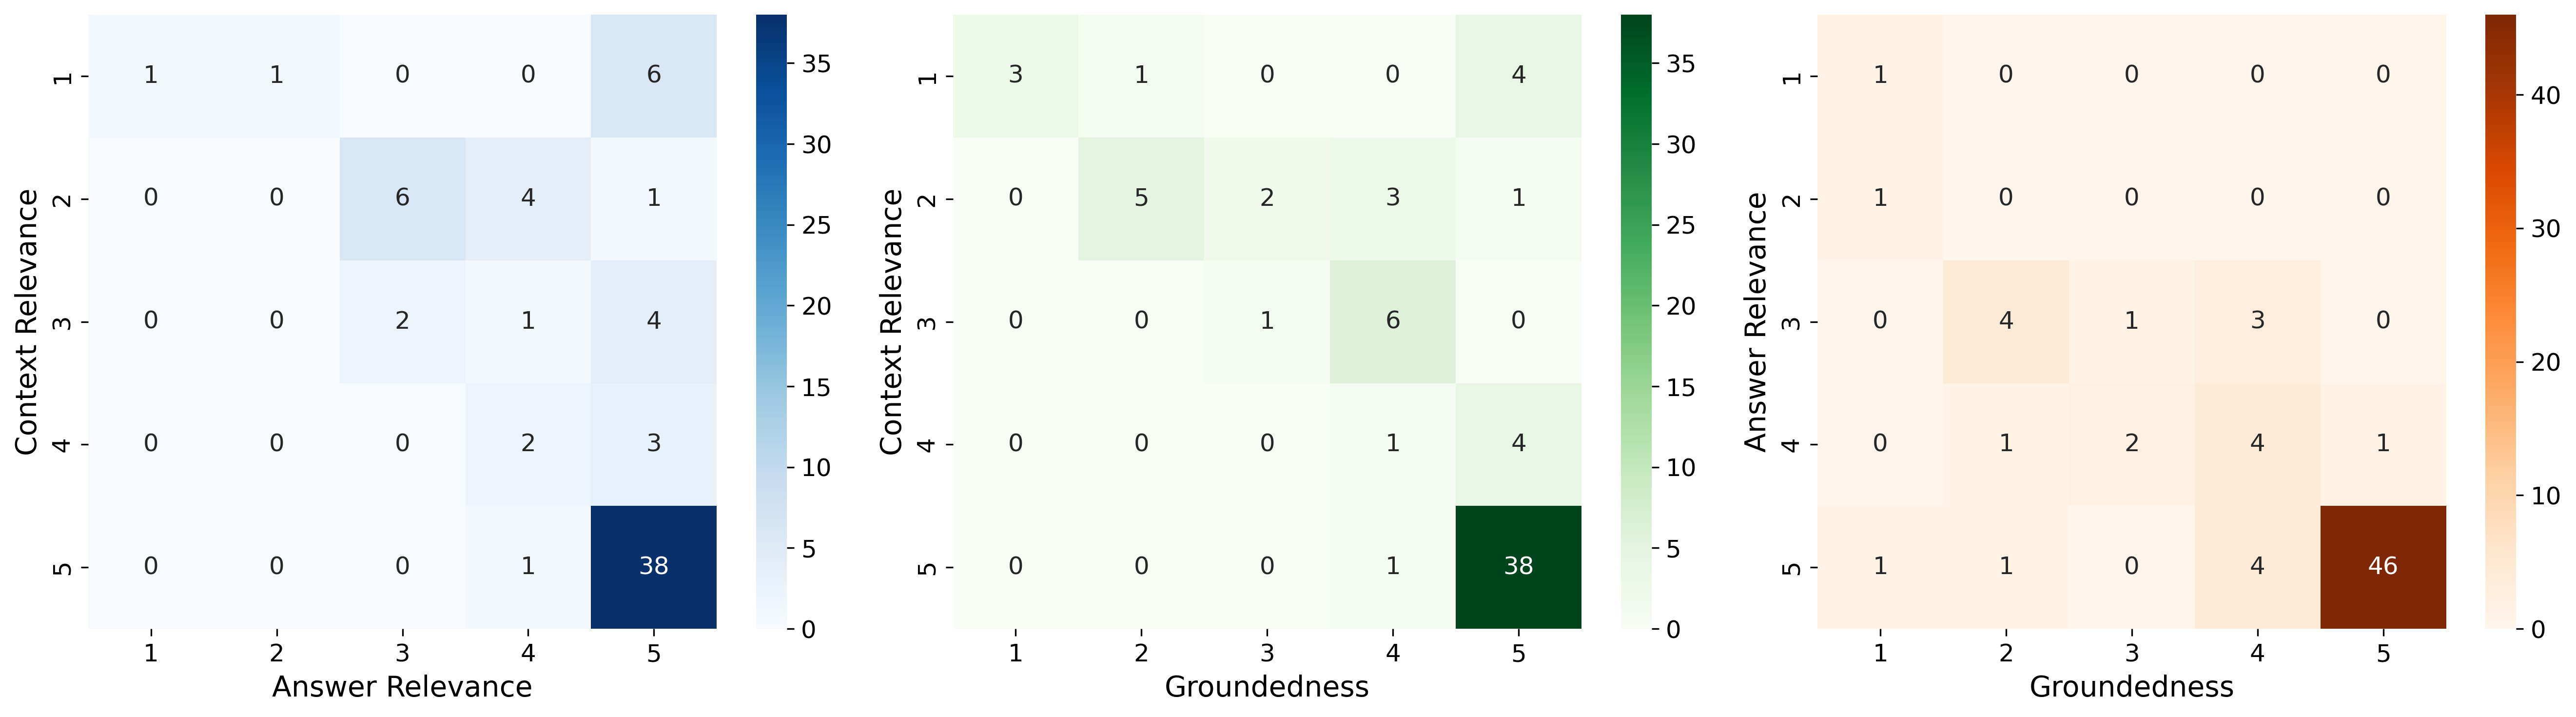

In [10]:
plot_heatmaps(rag_df_mistral)
# plot_heatmaps(zero_shot_df_mistral)

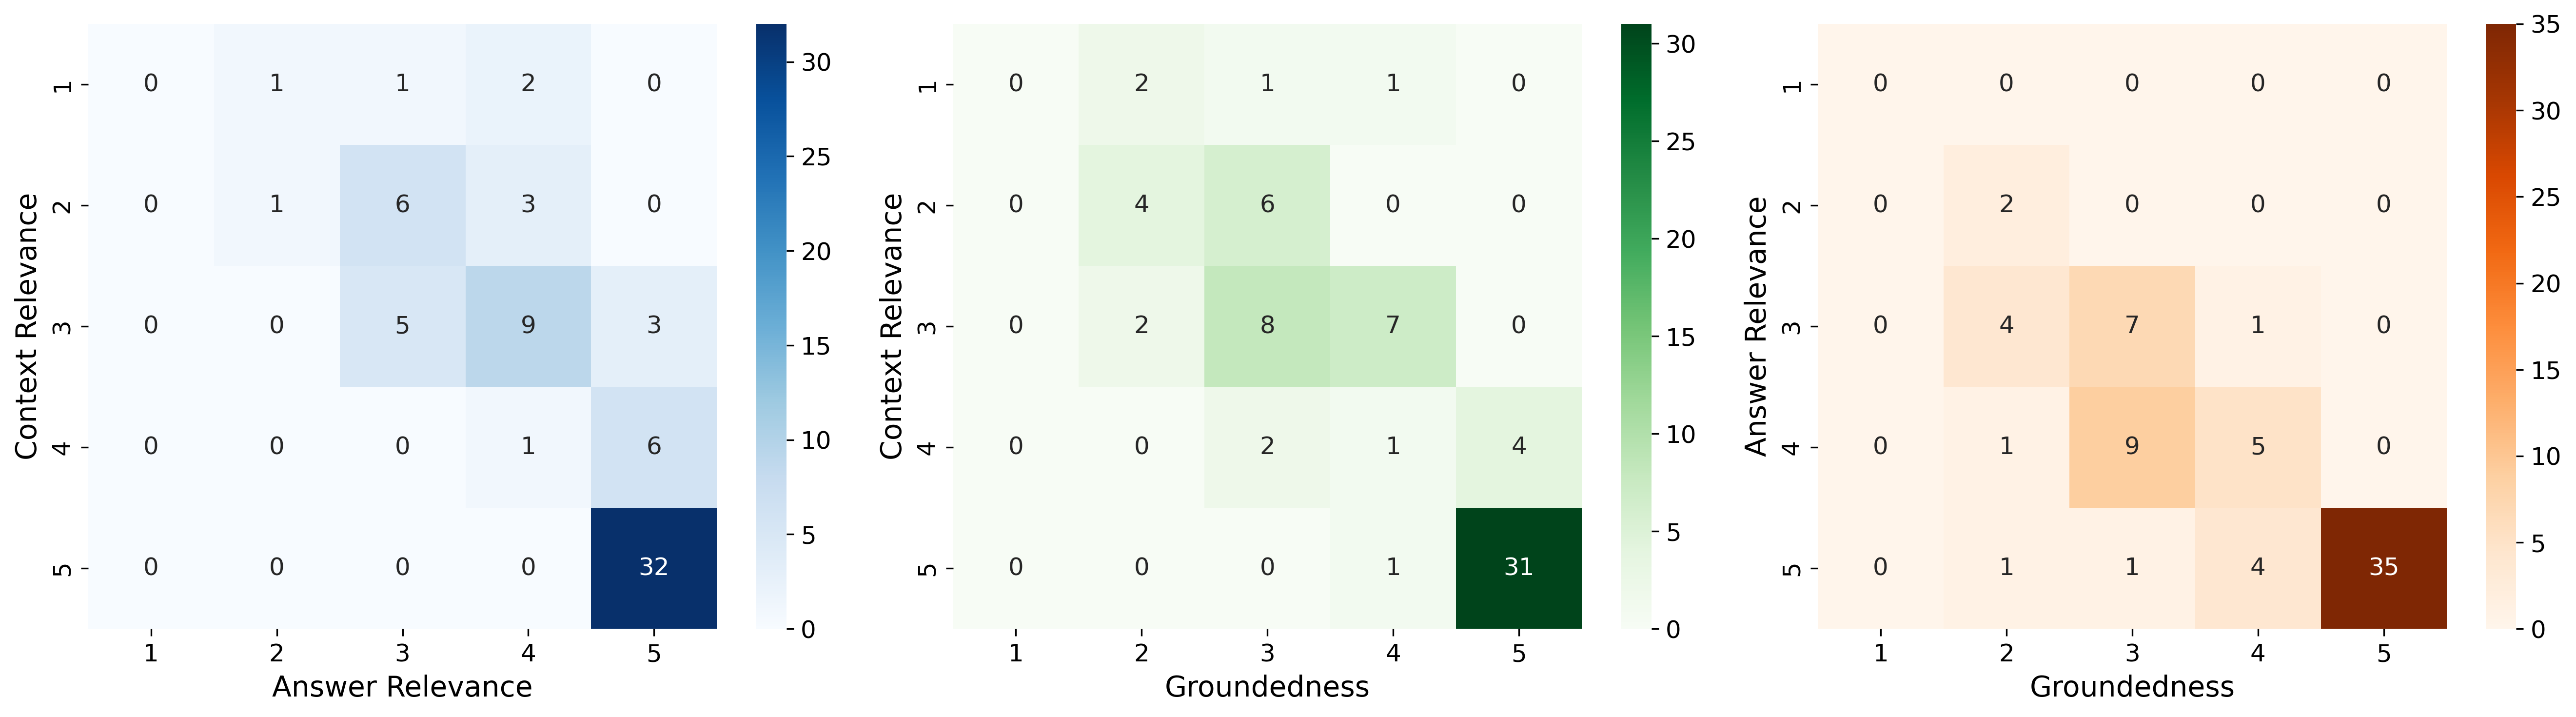

In [11]:
plot_heatmaps(rag_df_llama)
# plot_heatmaps(zero_shot_df_llama)

In [12]:
def double_plot(rag_df: pd.DataFrame, zero_shot_df: pd.DataFrame) -> None:

    fontsize = 16
    labelsize = 16
    annot_size = 16


    heatmap_context_answer_rag = make_full_heatmap_data(
        data=rag_df, group_col="context_relevance", value_col="answer_relevance"
    )
    heatmap_context_ground_rag = make_full_heatmap_data(
        data=rag_df, group_col="context_relevance", value_col="groundedness"
    )
    heatmap_answer_ground_rag = make_full_heatmap_data(
        data=rag_df, group_col="answer_relevance", value_col="groundedness"
    )

    heatmap_context_answer_zero_shot = make_full_heatmap_data(
        data=zero_shot_df, group_col="context_relevance", value_col="answer_relevance"
    )
    heatmap_context_ground_zero_shot = make_full_heatmap_data(
        data=zero_shot_df_mistral, group_col="context_relevance", value_col="groundedness"
    )
    heatmap_answer_ground_zero_shot = make_full_heatmap_data(
        data=zero_shot_df, group_col="answer_relevance", value_col="groundedness"
    )

    # Create a 2-row, 3-column subplot layout
    fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=300)  # Double height for two rows

    # ---- First set of heatmaps (row 0) ----
    sns_heat1 = sns.heatmap(
        heatmap_context_answer_rag, cmap="Blues", annot=True, ax=axes[0, 0], annot_kws={"size": annot_size}
    )
    axes[0, 0].set_xlabel("")
    axes[0, 0].set_ylabel("Context Relevance", fontsize=fontsize)
    axes[0, 0].tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
    axes[0, 0].tick_params(axis="y", labelsize=labelsize)
    sns_heat1.collections[0].colorbar.ax.tick_params(labelsize=labelsize)

    sns_heat2 = sns.heatmap(
        heatmap_context_ground_rag, cmap="Greens", annot=True, ax=axes[0, 1], annot_kws={"size": annot_size}
    )
    axes[0, 1].set_xlabel("")
    axes[0, 1].set_ylabel("Context Relevance", fontsize=fontsize)
    axes[0, 1].set_xlabel("")
    axes[0, 1].tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
    axes[0, 1].tick_params(axis="y", labelsize=labelsize)
    sns_heat2.collections[0].colorbar.ax.tick_params(labelsize=labelsize)

    sns_heat3 = sns.heatmap(
        heatmap_answer_ground_rag, cmap="Oranges", annot=True, ax=axes[0, 2], annot_kws={"size": annot_size}
    )
    axes[0, 2].set_xlabel("")
    axes[0, 2].set_ylabel("Answer Relevance", fontsize=fontsize)
    axes[0, 2].tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
    axes[0, 2].tick_params(axis="y", labelsize=labelsize)
    sns_heat3.collections[0].colorbar.ax.tick_params(labelsize=labelsize)

    # ---- Second set of heatmaps (row 1) ----
    sns_heat4 = sns.heatmap(
        heatmap_context_answer_zero_shot,
        cmap="Blues",
        annot=True,
        ax=axes[1, 0],
        annot_kws={"size": annot_size},
    )
    axes[1, 0].set_xlabel("Answer Relevance", fontsize=fontsize)
    axes[1, 0].set_ylabel("Context Relevance", fontsize=fontsize)
    axes[1, 0].tick_params(axis="both", labelsize=labelsize)
    sns_heat4.collections[0].colorbar.ax.tick_params(labelsize=labelsize)

    sns_heat5 = sns.heatmap(
        heatmap_context_ground_zero_shot,
        cmap="Greens",
        annot=True,
        ax=axes[1, 1],
        annot_kws={"size": annot_size},
    )
    axes[1, 1].set_xlabel("Groundedness", fontsize=fontsize)
    axes[1, 1].set_ylabel("Context Relevance", fontsize=fontsize)
    axes[1, 1].tick_params(axis="both", labelsize=labelsize)
    sns_heat5.collections[0].colorbar.ax.tick_params(labelsize=labelsize)

    sns_heat6 = sns.heatmap(
        heatmap_answer_ground_zero_shot,
        cmap="Oranges",
        annot=True,
        ax=axes[1, 2],
        annot_kws={"size": annot_size},
    )
    axes[1, 2].set_xlabel("Groundedness", fontsize=fontsize)
    axes[1, 2].set_ylabel("Answer Relevance", fontsize=fontsize)
    axes[1, 2].tick_params(axis="both", labelsize=labelsize)
    sns_heat6.collections[0].colorbar.ax.tick_params(labelsize=labelsize)

    # Final layout and show
    plt.tight_layout()
    plt.show()

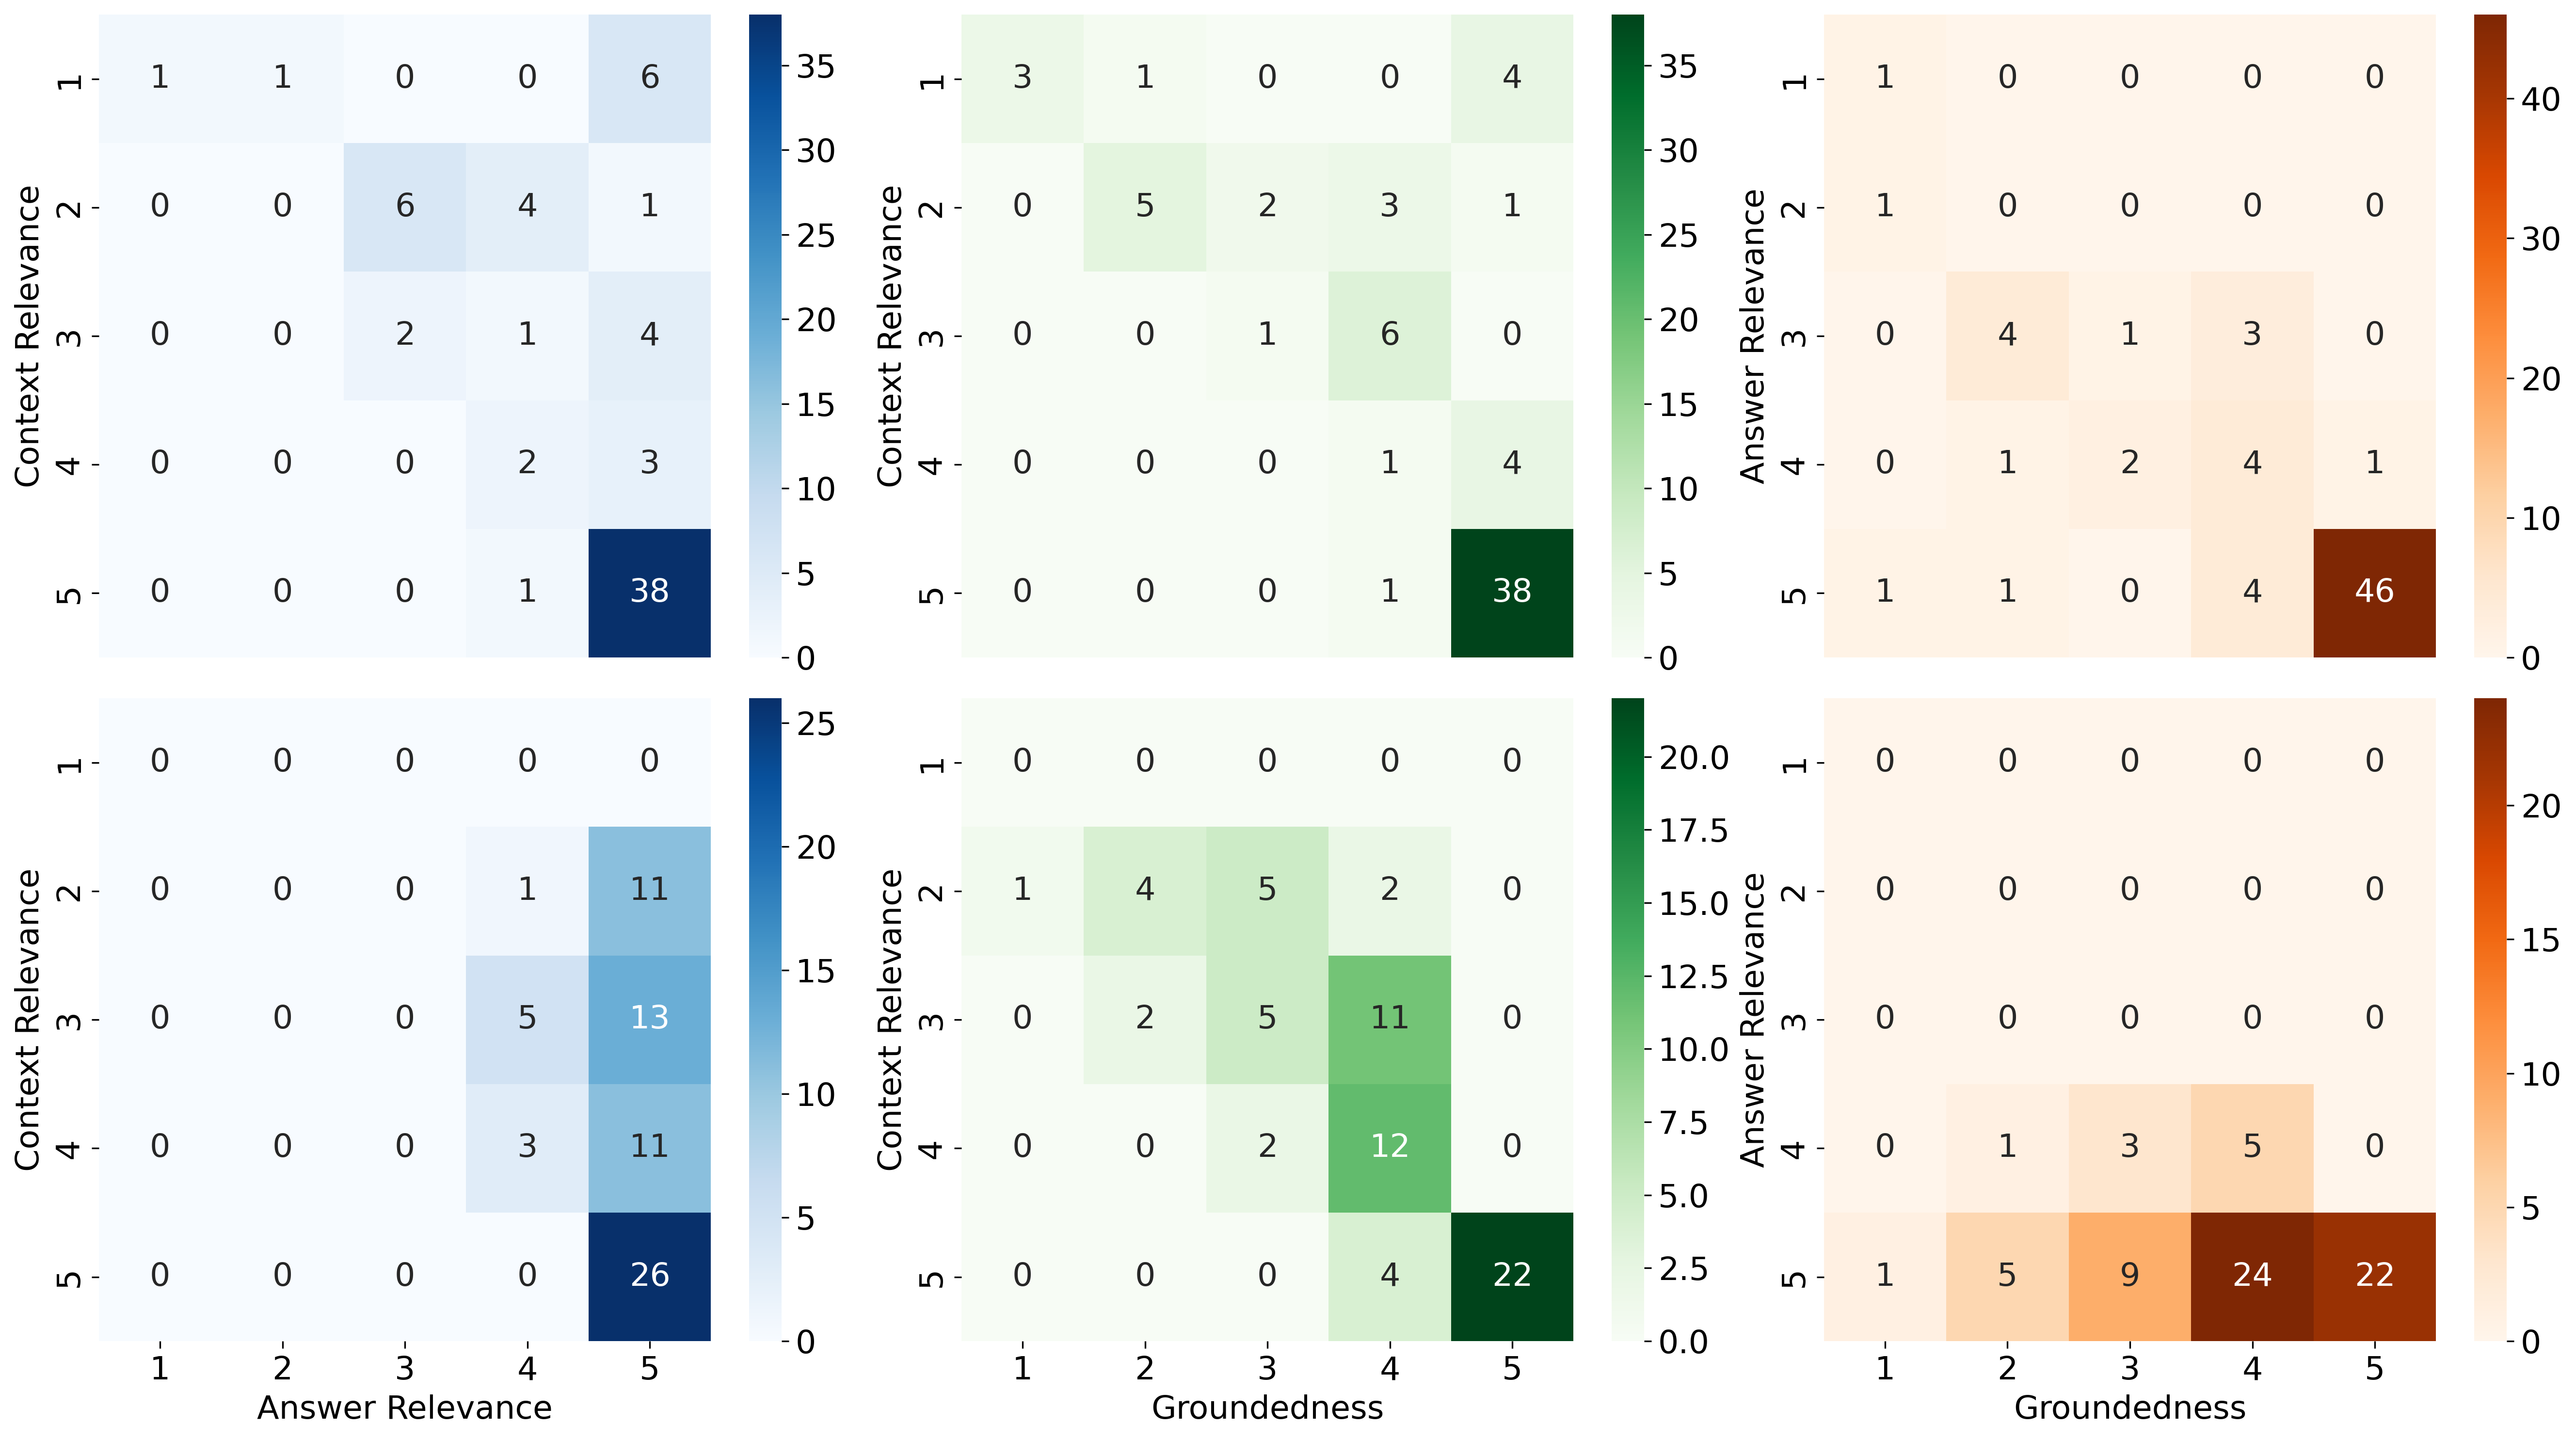

In [13]:
double_plot(rag_df_mistral, zero_shot_df_mistral)

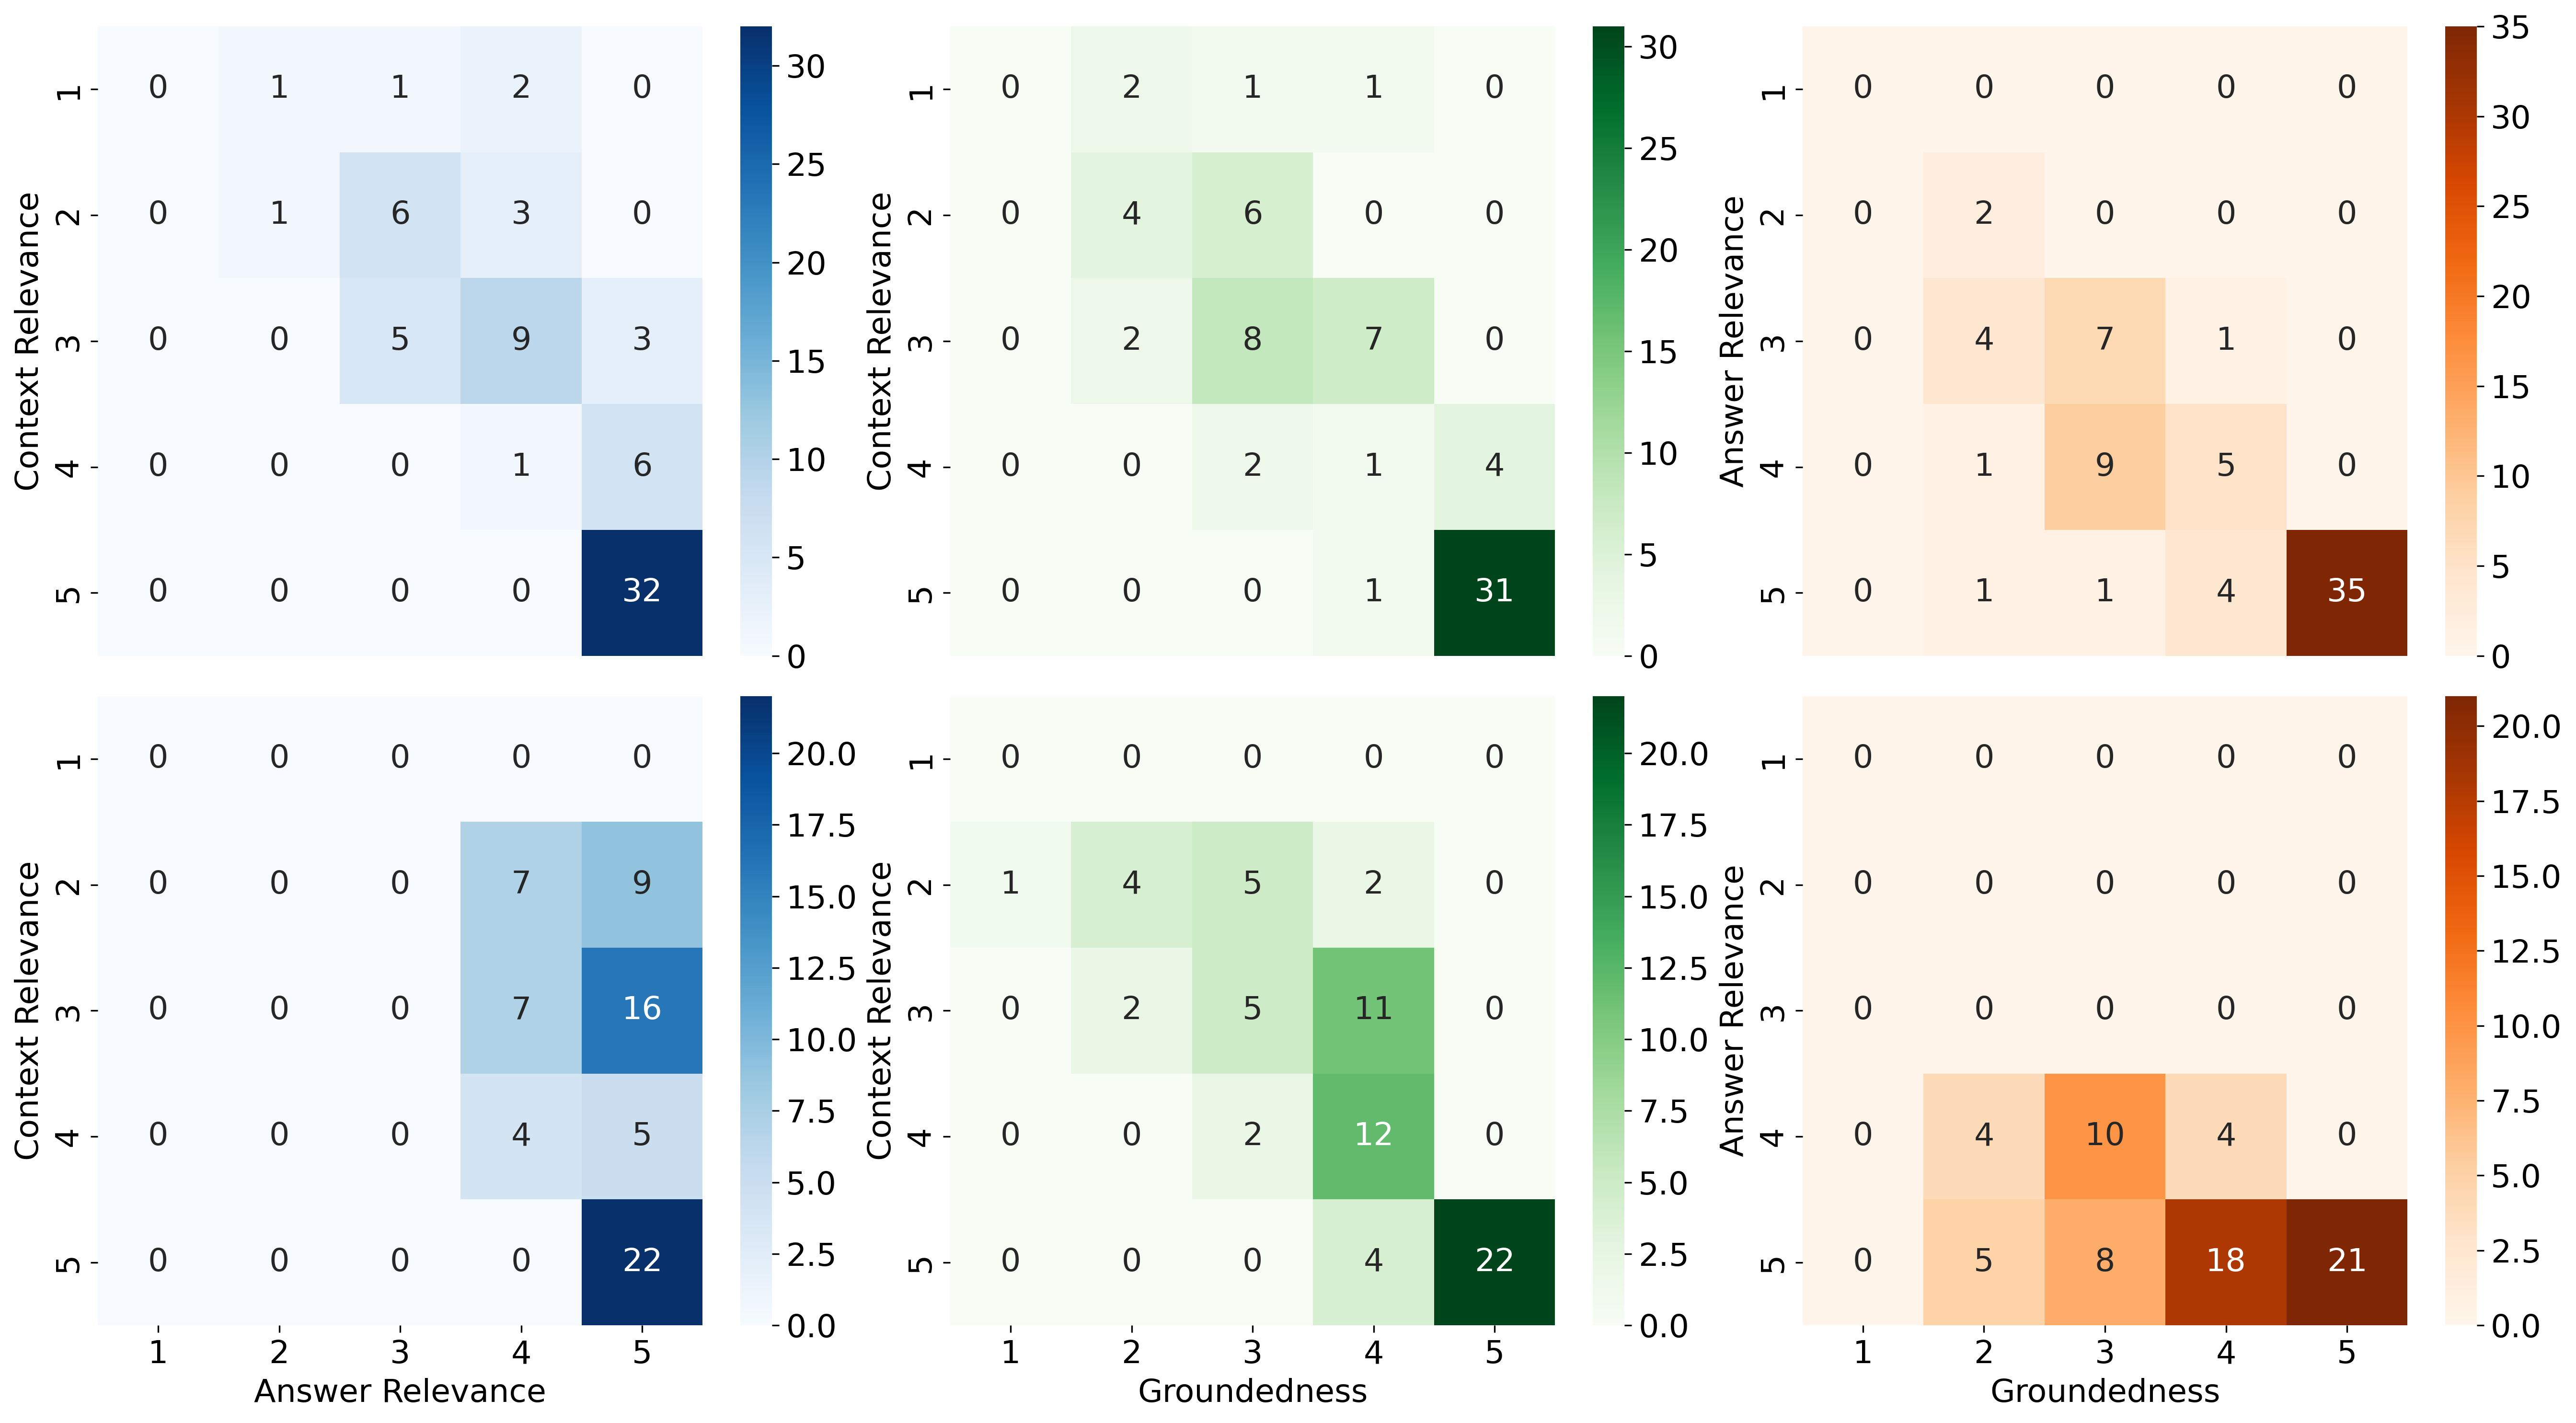

In [14]:
double_plot(rag_df_llama, zero_shot_df_llama)